---

# University of Liverpool

## COMP634 - Applied AI

---

This notebook is associated with Assignment 3. Use it to complete the assignment by following the instructions provided in each section. Each section includes a text cell outlining the requirements. For additional details, refer to Canvas.

Use this first cell to import the necessary libraries.

In [1]:
#imports
import random
from dataclasses import dataclass
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [ ]:
#Ensuring Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# 1. **Data Management**


In this part, you need to:

1.  define your experimental protocol (such as k-fold, cross validation, etc);
2.	create the dataloader to load the data.



In [ ]:
#Hyperparameters and Configuration
@dataclass
class CFG:
    data_path: str = "/content/assignment3-pos-dataset.txt"

    train_ratio: float = 0.80
    val_ratio: float = 0.10
    test_ratio: float = 0.10
    seed: int = 42

    batch_size: int = 32
    num_workers: int = 0

    grad_clip: float = 1.0

    lstm_embed_dim: int = 128
    lstm_hidden_size: int = 128
    lstm_layers: int = 2
    lstm_dropout: float = 0.5
    lstm_lr: float = 1e-3
    lstm_max_epochs: int = 30
    lstm_patience: int = 3

    tr_d_model: int = 256
    tr_heads: int = 8
    tr_layers: int = 3
    tr_ff_dim: int = 768
    tr_dropout: float = 0.2
    tr_lr: float = 1e-4
    tr_max_epochs: int = 30
    tr_patience: int = 3
    tr_max_len: int = 512

cfg = CFG()


In [ ]:
#Building word and tag vocabularies, including special tokens for padding and unknown words
def read_conll_sentences(path: str):
    sentences = []
    cur_tokens, cur_tags = [], []

    with open(path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()

            if line == "":
                if cur_tokens:
                    sentences.append((cur_tokens, cur_tags))
                cur_tokens, cur_tags = [], []
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            token = parts[0]
            tag = parts[-1]

            cur_tokens.append(token)
            cur_tags.append(tag)

    if cur_tokens:
        sentences.append((cur_tokens, cur_tags))

    return sentences

sentences = read_conll_sentences(cfg.data_path)
print("Num sentences:", len(sentences))
print("Example:", sentences[0][0][:10], sentences[0][1][:10])


Num sentences: 3914
Example: ['Pierre', 'Vinken', '61', 'years', 'old', 'will', 'join', 'the', 'board', 'as'] ['NNP', 'NNP', 'CD', 'NNS', 'JJ', 'MD', 'VB', 'DT', 'NN', 'IN']


In [ ]:
#converting word tokens and POS tags into numerical index representations using the previously constructed vocabularies
def data_report(sentences):
    lengths = []
    tag_counter = Counter()
    token_counter = Counter()
    weird = Counter()
    mismatched = 0

    for tokens, tags in sentences:
        if len(tokens) != len(tags):
            mismatched += 1
            continue

        lengths.append(len(tokens))
        tag_counter.update(tags)
        token_counter.update(tokens)

        for t in tokens:
            if len(t) > 25 or any(ch.isdigit() for ch in t) or ("http" in t.lower()):
                weird[t] += 1

    lengths = np.array(lengths)

    print("Mismatched sentences:", mismatched)
    print("Len min:", int(lengths.min()), "max:", int(lengths.max()), "mean:", float(lengths.mean()))
    print("Len p50:", int(np.percentile(lengths, 50)), "p90:", int(np.percentile(lengths, 90)), "p95:", int(np.percentile(lengths, 95)))
    print("Unique tokens:", len(token_counter))
    print("Unique tags:", len(tag_counter))
    print("Most common tags:", tag_counter.most_common(10))
    print("Rarest tags:", sorted(tag_counter.items(), key=lambda x: x[1])[:10])
    print("Weird token examples:", weird.most_common(10))

    return tag_counter

global_tag_counter = data_report(sentences)


Mismatched sentences: 0
Len min: 1 max: 171 mean: 21.042667347981606
Len p50: 20 p90: 34 p95: 39
Unique tokens: 11943
Unique tags: 33
Most common tags: [('NN', 13166), ('IN', 9857), ('NNP', 9410), ('DT', 8165), ('NNS', 6047), ('JJ', 5834), ('CD', 3546), ('VBD', 3043), ('RB', 2822), ('VB', 2554)]
Rarest tags: [('LS', 13), ('WP$', 14), ('PDT', 27), ('RBS', 35), ('EX', 88), ('RBR', 136), ('WRB', 178), ('JJS', 182), ('RP', 216), ('WP', 241)]
Weird token examples: [('10', 51), ('30', 47), ('50', 46), ('1988', 45), ('1990', 43), ('1', 43), ('15', 42), ('1989', 40), ('100', 40), ('500', 38)]


In [ ]:
#defining the experimental protocol by splitting the dataset using fixed random seeds for reproducibility
def split_sentences(sentences, train_ratio, val_ratio, test_ratio, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    idx = list(range(len(sentences)))
    rng = random.Random(seed)
    rng.shuffle(idx)

    n = len(idx)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    train = [sentences[i] for i in train_idx]
    val = [sentences[i] for i in val_idx]
    test = [sentences[i] for i in test_idx]
    return train, val, test

train_sents, val_sents, test_sents = split_sentences(
    sentences, cfg.train_ratio, cfg.val_ratio, cfg.test_ratio, cfg.seed
)

print("Train:", len(train_sents), "Val:", len(val_sents), "Test:", len(test_sents))


Train: 3131 Val: 391 Test: 392


In [ ]:
#custom PyTorch Dataset class to encapsulate encoded sentences and tags
PAD = "<PAD>"
UNK = "<UNK>"

def build_vocabs(train_sents):
    word_counter = Counter()
    tag_counter = Counter()

    for tokens, tags in train_sents:
        word_counter.update(tokens)
        tag_counter.update(tags)

    word2id = {PAD: 0, UNK: 1}
    for w in word_counter.keys():
        if w not in word2id:
            word2id[w] = len(word2id)

    tag2id = {PAD: 0}
    for t in tag_counter.keys():
        if t not in tag2id:
            tag2id[t] = len(tag2id)

    id2tag = {i: t for t, i in tag2id.items()}
    return word2id, tag2id, id2tag

word2id, tag2id, id2tag = build_vocabs(train_sents)
print("Vocab size:", len(word2id))
print("Num tags:", len(tag2id))


Vocab size: 10577
Num tags: 34


In [ ]:
def unk_rate(split_sents, word2id):
    total = 0
    unk = 0
    for tokens, _ in split_sents:
        for w in tokens:
            total += 1
            if w not in word2id:
                unk += 1
    return unk / max(total, 1)

print("UNK rate val:", unk_rate(val_sents, word2id))
print("UNK rate test:", unk_rate(test_sents, word2id))


UNK rate val: 0.09612968082432773
UNK rate test: 0.08401614283967225


In [ ]:
#defining the custom PyTorch Dataset and DataLoaders
class PosDataset(Dataset):
    def __init__(self, sents, word2id, tag2id):
        self.sents = sents
        self.word2id = word2id
        self.tag2id = tag2id

    def __len__(self):
        return len(self.sents)

    def __getitem__(self, idx):
        tokens, tags = self.sents[idx]
        x = [self.word2id.get(w, self.word2id[UNK]) for w in tokens]
        y = [self.tag2id[t] for t in tags]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long), len(x)

def collate_batch(batch):
    xs, ys, lens = zip(*batch)
    lens = torch.tensor(lens, dtype=torch.long)

    max_len = int(lens.max().item())
    x_pad = torch.zeros(len(xs), max_len, dtype=torch.long)
    y_pad = torch.zeros(len(xs), max_len, dtype=torch.long)
    mask = torch.zeros(len(xs), max_len, dtype=torch.bool)

    for i, (x, y, L) in enumerate(zip(xs, ys, lens)):
        x_pad[i, :L] = x
        y_pad[i, :L] = y
        mask[i, :L] = True

    return x_pad, y_pad, mask, lens

train_ds = PosDataset(train_sents, word2id, tag2id)
val_ds = PosDataset(val_sents, word2id, tag2id)
test_ds = PosDataset(test_sents, word2id, tag2id)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, collate_fn=collate_batch)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, collate_fn=collate_batch)


---

# 2. **Neural Networks**

Here, you need to:

1.	create an efficient and robust Recurrent Neural Network (RNN) (such as RNN, GRU, LSTM) to tackle the problem;
2.	create an efficient and robust Transformer Network to tackle the problem;
3.	define the necessary components to train the networks (that is, loss function, optimizers, etc);
4.	train the models;
5.	for all training procedures, separately plot the loss and accuracy with respect to the epoch/iteration.

In [ ]:
#Bidirectional LSTM (BiLSTM) neural network architecture
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, num_tags, embed_dim, hidden_size, num_layers, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_tags)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        out = self.dropout(out)
        logits = self.classifier(out)
        return logits


In [ ]:
#Transformer architecture
class TransformerTagger(nn.Module):
    def __init__(self, vocab_size, num_tags, cfg, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, cfg.tr_d_model, padding_idx=pad_idx)
        self.pos_embedding = nn.Embedding(cfg.tr_max_len, cfg.tr_d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.tr_d_model,
            nhead=cfg.tr_heads,
            dim_feedforward=cfg.tr_ff_dim,
            dropout=cfg.tr_dropout,
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.tr_layers)
        self.dropout = nn.Dropout(cfg.tr_dropout)
        self.classifier = nn.Linear(cfg.tr_d_model, num_tags)

    def forward(self, x, mask):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)

        h = self.embedding(x) + self.pos_embedding(pos)
        h = self.dropout(h)

        key_padding_mask = ~mask
        h = self.encoder(h, src_key_padding_mask=key_padding_mask)

        logits = self.classifier(h)
        return logits


In [ ]:
#Early Stopping mechanism
class EarlyStopping:
    def __init__(self, patience=3, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.counter = 0
        self.best_state = None

    def step(self, metric, model):
        improved = False
        if self.best is None:
            improved = True
        elif self.mode == "max" and metric > self.best:
            improved = True
        elif self.mode == "min" and metric < self.best:
            improved = True

        if improved:
            self.best = metric
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        return improved

    def should_stop(self):
        return self.counter >= self.patience


In [ ]:
#Training and Evaluation
def run_epoch(model, loader, optimizer=None, model_kind="lstm", grad_clip=1.0):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    loss_fn = nn.CrossEntropyLoss(ignore_index=0 , label_smoothing=0.1)

    total_loss = 0.0
    all_true, all_pred = [], []

    for x, y, mask, lengths in loader:
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)
        lengths = lengths.to(device)

        with torch.set_grad_enabled(train_mode):
            if model_kind == "lstm":
                logits = model(x, lengths)
            else:
                logits = model(x, mask)

            B, T, C = logits.shape
            loss = loss_fn(logits.view(B * T, C), y.view(B * T))

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

        total_loss += float(loss.item())

        preds = logits.argmax(dim=-1)
        valid = mask.bool()

        all_true.extend(y[valid].detach().cpu().tolist())
        all_pred.extend(preds[valid].detach().cpu().tolist())

    avg_loss = total_loss / max(len(loader), 1)
    acc = accuracy_score(all_true, all_pred) if len(all_true) else 0.0
    macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0) if len(all_true) else 0.0

    return avg_loss, acc, macro_f1


In [ ]:
lstm_model = BiLSTMTagger(
    vocab_size=len(word2id),
    num_tags=len(tag2id),
    embed_dim=cfg.lstm_embed_dim,
    hidden_size=cfg.lstm_hidden_size,
    num_layers=cfg.lstm_layers,
    dropout=cfg.lstm_dropout,
    pad_idx=0
).to(device)

lstm_optim = torch.optim.AdamW(
    lstm_model.parameters(),
    lr=cfg.lstm_lr,
    weight_decay=0.01
)

lstm_hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
stopper = EarlyStopping(patience=cfg.lstm_patience, mode="max")

for epoch in range(1, cfg.lstm_max_epochs + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(lstm_model, train_loader, optimizer=lstm_optim, model_kind="lstm", grad_clip=cfg.grad_clip)
    va_loss, va_acc, va_f1 = run_epoch(lstm_model, val_loader, optimizer=None, model_kind="lstm")

    lstm_hist["train_loss"].append(tr_loss)
    lstm_hist["val_loss"].append(va_loss)
    lstm_hist["train_acc"].append(tr_acc)
    lstm_hist["val_acc"].append(va_acc)
    lstm_hist["val_f1"].append(va_f1)

    print(f"Epoch {epoch:02d}  train loss {tr_loss:.4f}  val loss {va_loss:.4f}  val macroF1 {va_f1:.4f}")

    stopper.step(va_f1, lstm_model)
    if stopper.should_stop():
        print("Early stopping BiLSTM")
        break

lstm_model.load_state_dict(stopper.best_state)
print("Best BiLSTM val macroF1:", stopper.best)


Epoch 01  train loss 2.4757  val loss 1.8287  val macroF1 0.3523
Epoch 02  train loss 1.6360  val loss 1.4425  val macroF1 0.5075
Epoch 03  train loss 1.3737  val loss 1.3000  val macroF1 0.5627
Epoch 04  train loss 1.2292  val loss 1.2181  val macroF1 0.6313
Epoch 05  train loss 1.1314  val loss 1.1551  val macroF1 0.6868
Epoch 06  train loss 1.0578  val loss 1.1203  val macroF1 0.7168
Epoch 07  train loss 1.0026  val loss 1.0966  val macroF1 0.7264
Epoch 08  train loss 0.9593  val loss 1.0783  val macroF1 0.7371
Epoch 09  train loss 0.9242  val loss 1.0580  val macroF1 0.7480
Epoch 10  train loss 0.8949  val loss 1.0552  val macroF1 0.7564
Epoch 11  train loss 0.8709  val loss 1.0523  val macroF1 0.7647
Epoch 12  train loss 0.8503  val loss 1.0487  val macroF1 0.7662
Epoch 13  train loss 0.8331  val loss 1.0491  val macroF1 0.7781
Epoch 14  train loss 0.8203  val loss 1.0572  val macroF1 0.7807
Epoch 15  train loss 0.8064  val loss 1.0481  val macroF1 0.7805
Epoch 16  train loss 0.79

In [ ]:
tr_model = TransformerTagger(
    vocab_size=len(word2id),
    num_tags=len(tag2id),
    cfg=cfg,
    pad_idx=0
).to(device)

tr_optim = torch.optim.AdamW(tr_model.parameters(), lr=cfg.tr_lr, weight_decay=0.01)

tr_hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
stopper = EarlyStopping(patience=cfg.tr_patience, mode="max")

for epoch in range(1, cfg.tr_max_epochs + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(tr_model, train_loader, optimizer=tr_optim, model_kind="transformer", grad_clip=cfg.grad_clip)
    va_loss, va_acc, va_f1 = run_epoch(tr_model, val_loader, optimizer=None, model_kind="transformer")

    tr_hist["train_loss"].append(tr_loss)
    tr_hist["val_loss"].append(va_loss)
    tr_hist["train_acc"].append(tr_acc)
    tr_hist["val_acc"].append(va_acc)
    tr_hist["val_f1"].append(va_f1)

    print(f"Epoch {epoch:02d}  train loss {tr_loss:.4f}  val loss {va_loss:.4f}  val macroF1 {va_f1:.4f}")

    stopper.step(va_f1, tr_model)
    if stopper.should_stop():
        print("Early stopping Transformer")
        break

tr_model.load_state_dict(stopper.best_state)
print("Best Transformer val macroF1:", stopper.best)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 01  train loss 2.7081  val loss 2.1888  val macroF1 0.2796
Epoch 02  train loss 2.1245  val loss 1.9297  val macroF1 0.4149
Epoch 03  train loss 1.9438  val loss 1.8202  val macroF1 0.4658
Epoch 04  train loss 1.8446  val loss 1.7525  val macroF1 0.5246
Epoch 05  train loss 1.7763  val loss 1.6995  val macroF1 0.5611
Epoch 06  train loss 1.7233  val loss 1.6519  val macroF1 0.5705
Epoch 07  train loss 1.6711  val loss 1.6160  val macroF1 0.5970
Epoch 08  train loss 1.6272  val loss 1.5824  val macroF1 0.6093
Epoch 09  train loss 1.5862  val loss 1.5433  val macroF1 0.6152
Epoch 10  train loss 1.5479  val loss 1.5083  val macroF1 0.6304
Epoch 11  train loss 1.5074  val loss 1.4713  val macroF1 0.6450
Epoch 12  train loss 1.4713  val loss 1.4500  val macroF1 0.6375
Epoch 13  train loss 1.4298  val loss 1.4203  val macroF1 0.6475
Epoch 14  train loss 1.3989  val loss 1.3858  val macroF1 0.6616
Epoch 15  train loss 1.3643  val loss 1.3608  val macroF1 0.6659
Epoch 16  train loss 1.33

In [ ]:
def plot_history_side_by_side(lstm_hist, tr_hist):
    epochs_lstm = list(range(1, len(lstm_hist["train_loss"]) + 1))
    epochs_tr = list(range(1, len(tr_hist["train_loss"]) + 1))

    #  LOSS
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_lstm, lstm_hist["train_loss"], label="train")
    plt.plot(epochs_lstm, lstm_hist["val_loss"], label="val")
    plt.title("BiLSTM loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_tr, tr_hist["train_loss"], label="train")
    plt.plot(epochs_tr, tr_hist["val_loss"], label="val")
    plt.title("Transformer loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

    #  ACCURACY
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_lstm, lstm_hist["train_acc"], label="train")
    plt.plot(epochs_lstm, lstm_hist["val_acc"], label="val")
    plt.title("BiLSTM accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_tr, tr_hist["train_acc"], label="train")
    plt.plot(epochs_tr, tr_hist["val_acc"], label="val")
    plt.title("Transformer accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    #  MACRO F1 (validation only)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_lstm, lstm_hist["val_f1"], label="val macro F1")
    plt.title("BiLSTM macro F1")
    plt.xlabel("epoch")
    plt.ylabel("macro F1")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_tr, tr_hist["val_f1"], label="val macro F1")
    plt.title("Transformer macro F1")
    plt.xlabel("epoch")
    plt.ylabel("macro F1")
    plt.legend()

    plt.tight_layout()
    plt.show()


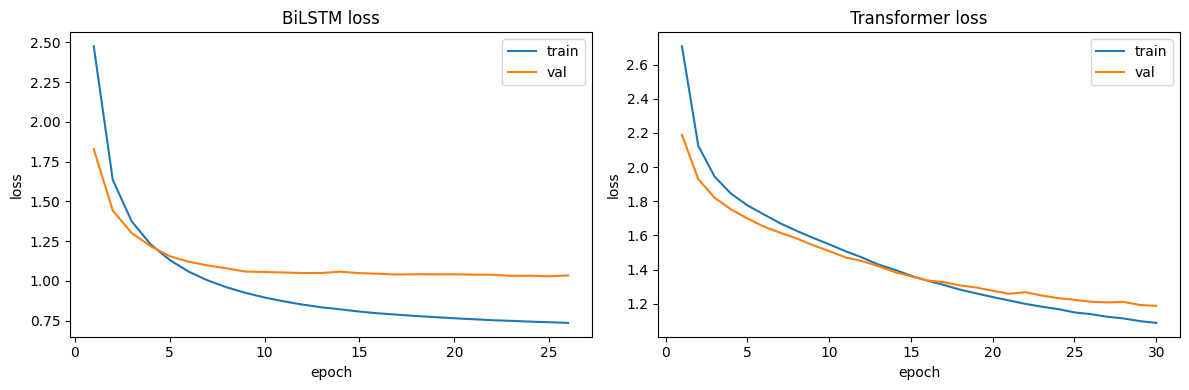

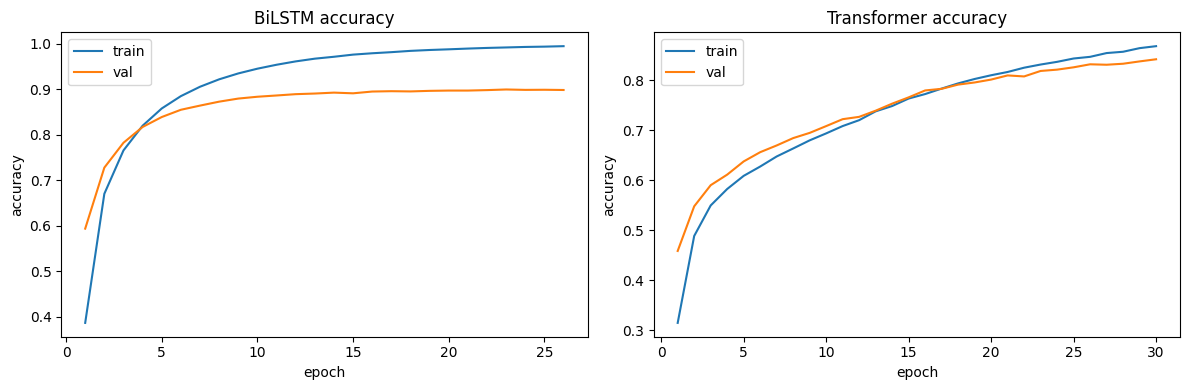

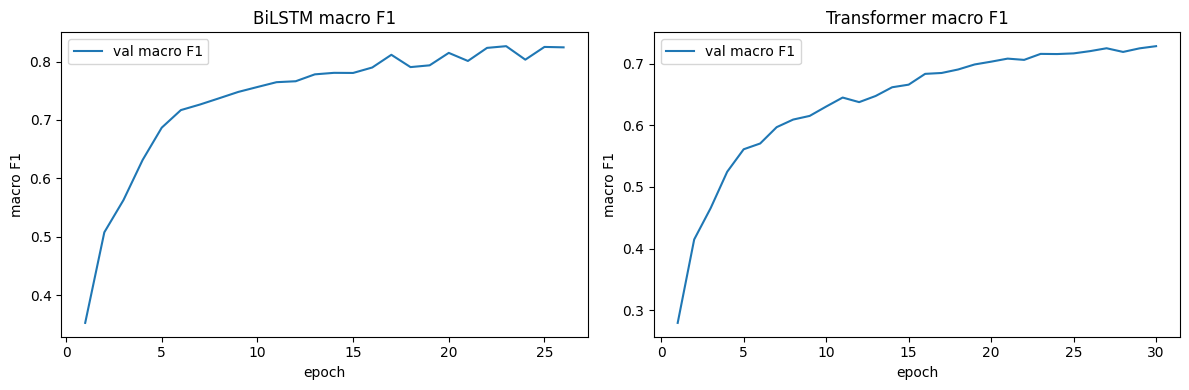

In [ ]:
plot_history_side_by_side(lstm_hist, tr_hist)


In [ ]:
def collect_predictions(model, loader, model_kind):
    model.eval()
    all_true, all_pred = [], []

    with torch.no_grad():
        for x, y, mask, lengths in loader:
            x = x.to(device)
            y = y.to(device)
            mask = mask.to(device)
            lengths = lengths.to(device)

            if model_kind == "lstm":
                logits = model(x, lengths)
            else:
                logits = model(x, mask)

            preds = logits.argmax(dim=-1)
            valid = mask.bool()

            all_true.extend(y[valid].detach().cpu().tolist())
            all_pred.extend(preds[valid].detach().cpu().tolist())

    return all_true, all_pred

def sentence_exact_match(model, loader, model_kind):
    model.eval()
    exact = 0
    total = 0

    with torch.no_grad():
        for x, y, mask, lengths in loader:
            x = x.to(device)
            y = y.to(device)
            mask = mask.to(device)
            lengths = lengths.to(device)

            if model_kind == "lstm":
                preds = model(x, lengths).argmax(dim=-1)
            else:
                preds = model(x, mask).argmax(dim=-1)

            for i in range(y.size(0)):
                valid = mask[i].bool()
                if torch.equal(preds[i][valid], y[i][valid]):
                    exact += 1
                total += 1

    return exact / max(total, 1)


---

# 3. **Evaluate models**

Here, you need to:

1.	evaluate the model (the best one you obtained in the above stage) on the appropriate set.


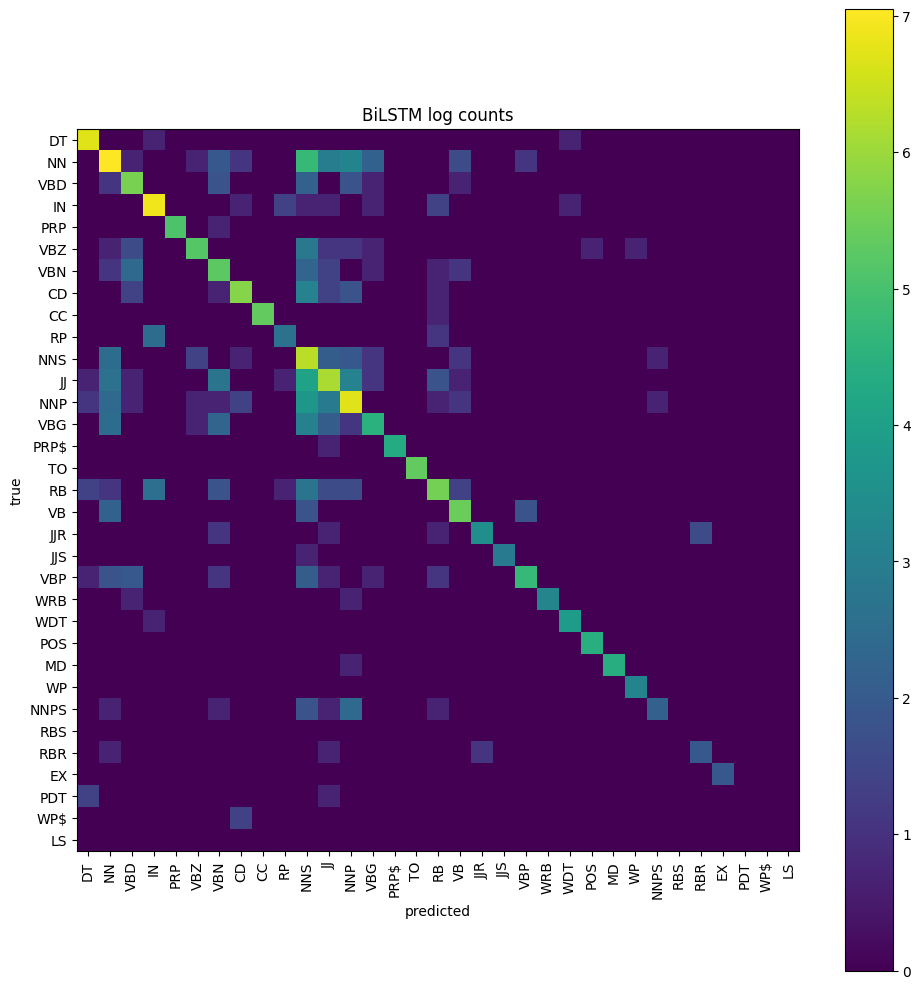

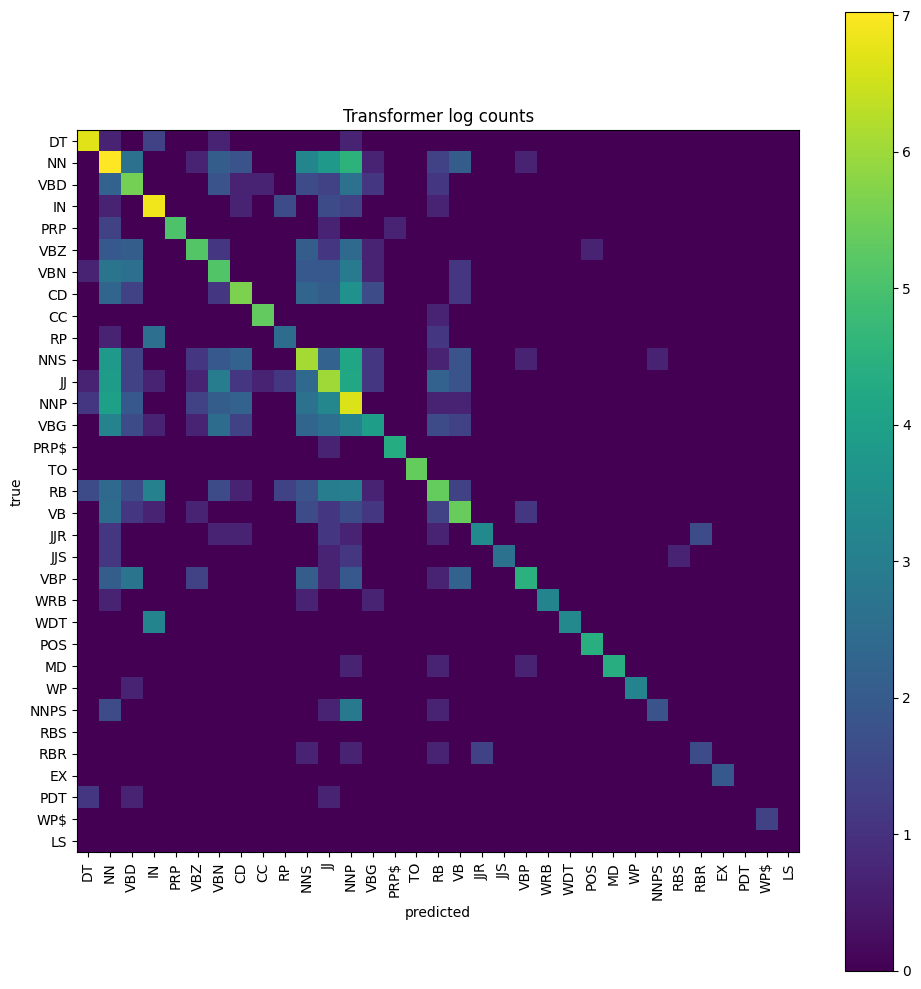

In [ ]:
def plot_cm_log(true_ids, pred_ids, id2tag, title):
    true_tags = [id2tag[i] for i in true_ids]
    pred_tags = [id2tag[i] for i in pred_ids]
    labels = [id2tag[i] for i in sorted(id2tag.keys()) if id2tag[i] != PAD]

    cm = confusion_matrix(true_tags, pred_tags, labels=labels)

    plt.figure(figsize=(10, 10))
    plt.imshow(np.log1p(cm), interpolation="nearest")
    plt.title(title + " log counts")
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_cm_log(b_true, b_pred, id2tag, "BiLSTM")
plot_cm_log(t_true, t_pred, id2tag, "Transformer")


In [ ]:
def print_report(true_ids, pred_ids, id2tag, title):
    true_tags = [id2tag[i] for i in true_ids]
    pred_tags = [id2tag[i] for i in pred_ids]
    print(title)
    print(classification_report(true_tags, pred_tags, zero_division=0))

print_report(b_true, b_pred, id2tag, "BiLSTM report")
print_report(t_true, t_pred, id2tag, "Transformer report")


BiLSTM report
              precision    recall  f1-score   support

          CC       1.00      1.00      1.00       209
          CD       0.97      0.90      0.93       352
          DT       0.99      1.00      0.99       825
          EX       1.00      1.00      1.00         6
          IN       0.97      0.99      0.98       986
          JJ       0.87      0.80      0.83       583
         JJR       0.94      0.80      0.86        40
         JJS       1.00      0.95      0.97        19
          MD       1.00      0.99      0.99        81
          NN       0.94      0.87      0.90      1326
         NNP       0.91      0.91      0.91       900
        NNPS       0.80      0.30      0.43        27
         NNS       0.63      0.94      0.76       586
         PDT       0.00      0.00      0.00         4
         POS       0.99      1.00      0.99        83
         PRP       1.00      0.99      1.00       161
        PRP$       1.00      0.99      0.99        77
          RB 

In [ ]:
b_true, b_pred = collect_predictions(lstm_model, test_loader, "lstm")
t_true, t_pred = collect_predictions(tr_model, test_loader, "transformer")

b_acc = accuracy_score(b_true, b_pred)
b_macro = f1_score(b_true, b_pred, average="macro", zero_division=0)
b_weighted = f1_score(b_true, b_pred, average="weighted", zero_division=0)
b_em = sentence_exact_match(lstm_model, test_loader, "lstm")

t_acc = accuracy_score(t_true, t_pred)
t_macro = f1_score(t_true, t_pred, average="macro", zero_division=0)
t_weighted = f1_score(t_true, t_pred, average="weighted", zero_division=0)
t_em = sentence_exact_match(tr_model, test_loader, "transformer")

print("Model comparison on test set")
print(f"{'Model':<12} {'Acc':<8} {'MacroF1':<10} {'WeightedF1':<12} {'SentEM':<8}")
print(f"{'BiLSTM':<12} {b_acc:<8.4f} {b_macro:<10.4f} {b_weighted:<12.4f} {b_em:<8.4f}")
print(f"{'Transformer':<12} {t_acc:<8.4f} {t_macro:<10.4f} {t_weighted:<12.4f} {t_em:<8.4f}")


Model comparison on test set
Model        Acc      MacroF1    WeightedF1   SentEM  
BiLSTM       0.9101   0.8306     0.9110       0.2245  
Transformer  0.8509   0.7689     0.8483       0.1097  
